In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

%env XLA_PYTHON_CLIENT_PREALLOCATE=False

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl_small"): #and "merge" in file
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, None, None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8], None), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [5]:
PKLs[40]['res'][8]

Array([[-28.551195  , -27.837751  , -24.009546  , -18.594286  ,
        -20.173075  , -10.009422  ,   0.        ,   0.        ,
          0.        ],
       [-28.00715   , -27.33799   , -23.713106  , -25.314161  ,
        -18.055868  ,  -6.8499093 ,   0.        ,   0.        ,
          0.        ],
       [-28.420626  , -27.77278   , -24.051058  , -25.220682  ,
        -14.959921  ,  -6.152351  ,  -0.68312484,   0.        ,
          0.        ],
       [-28.143919  , -27.391205  , -23.350403  , -17.73341   ,
        -20.948757  , -13.257869  ,   0.        ,   0.        ,
          0.        ],
       [-27.344097  , -26.621983  , -22.575968  , -21.06158   ,
        -14.036861  , -12.463298  ,   0.        ,   0.        ,
          0.        ]], dtype=float32)

In [42]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'adaptive RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

In [119]:
def idx_first_temp_1(arr):
    return np.vectorize(lambda x: np.argwhere(x==1)[0,0], signature="(n)->()")(arr)
i=0
max_size = PKLs[i]['res'][6].shape[1]
num_para = PKLs[i]['res'][6].shape[0]
max_temp_idx = np.max(np.array([idx_first_temp_1(PKLs[i]['res'][6]) for i in range(n)]))

max_temp_idx_per_proposal = {
    proposal:  np.max(np.array([idx_first_temp_1(PKLs[i]['res'][6]) for i in idx_proposal[proposal]])) for proposal in idx_proposal}

log_normalization_constants = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx_per_proposal[proposal]+1] for idx in idx_proposal[proposal]] for proposal in idx_proposal}

def facteur(idx):
    M = PKLs[idx]['config']['num_parallel_chain']
    P = PKLs[idx]['config']['num_mcmc_steps']
    T = np.argmin(PKLs[idx]['res'][6]==1, axis=1)
    return T/T

file_path = 'log_normalization_constants.pkl'

with open(file_path, 'wb') as file:# Specify the file path where you want to save the pickle file
    file_path = 'log_normalization_constants.pkl'
    pickle.dump(log_normalization_constants, file)

log_normalization_constants_facteur = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx_per_proposal[proposal]+1] * \
                                                  idx_first_temp_1(PKLs[idx]['res'][6]).reshape((num_para, 1)) for idx in idx_proposal[proposal]] for proposal in idx_proposal}


In [94]:
np.argwhere(PKLs[idx]['res'][6][3]==1)[0,0]

7

In [56]:
pd.DataFrame(log_normalization_constants_facteur['pCN'][0], columns=list(range(1, max_temp_idx_per_proposal['pCN']+1))).assign(Type=proposal) 

,1,2,3,4,5,Type
0,-27.694822,-23.381332,-23.349665,-13.345756,-8.633763,build_build_uncoupled_autoregressive_gaussian_...
1,-27.719633,-21.265366,-18.609121,-24.890306,-6.174627,build_build_uncoupled_autoregressive_gaussian_...
2,-27.956985,-23.927895,-18.333841,-13.050259,-8.426483,build_build_uncoupled_autoregressive_gaussian_...
3,-27.374733,-24.877262,-18.757994,-27.737541,-4.078002,build_build_uncoupled_autoregressive_gaussian_...
4,-28.023258,-24.126465,-21.833477,-15.179666,-10.490515,build_build_uncoupled_autoregressive_gaussian_...


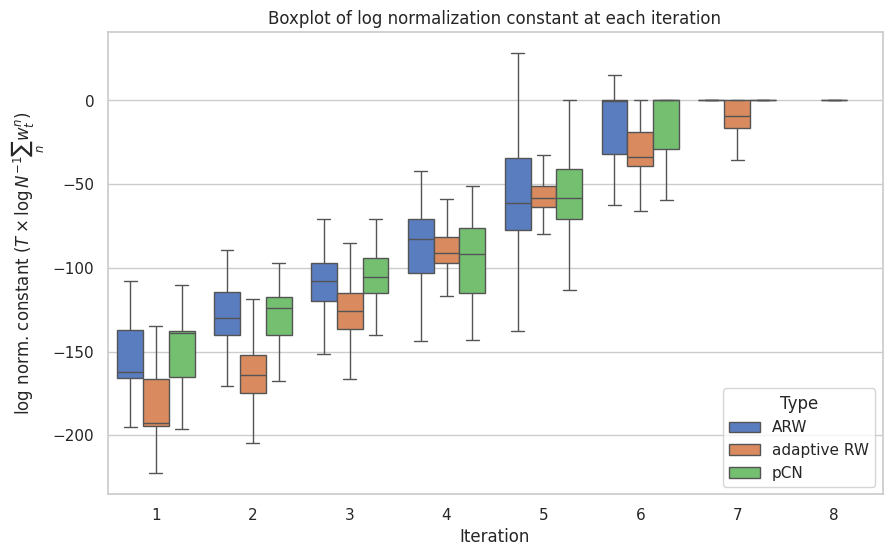

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#construct all dfs

my_dfs = {proposal: 
              [
                  pd.DataFrame(log_normalization_constants_facteur[proposal][idx], columns=list(range(1, max_temp_idx_per_proposal[proposal]+1))).assign(Type=proposal) 
                  for idx in range(len(idx_proposal[proposal]))]
           for proposal in idx_proposal
         }

#


# Combine the DataFrames
combined_df = pd.concat([pd.concat([df for df in my_dfs[proposal]]) for proposal in idx_proposal])

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')


# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', hue='Type', data=melted_df, showfliers=False)

# Add titles and labels
plt.title('Boxplot of log normalization constant at each iteration')
plt.xlabel('Iteration')
plt.ylabel(r'log norm. constant ($T\times \log N^{-1} \sum_n w_t^n$)')

# Show the plot
plt.savefig(DIR+"boxplot.png")

/tmp/ipykernel_624583/3676243617.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_624583/3676243617.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


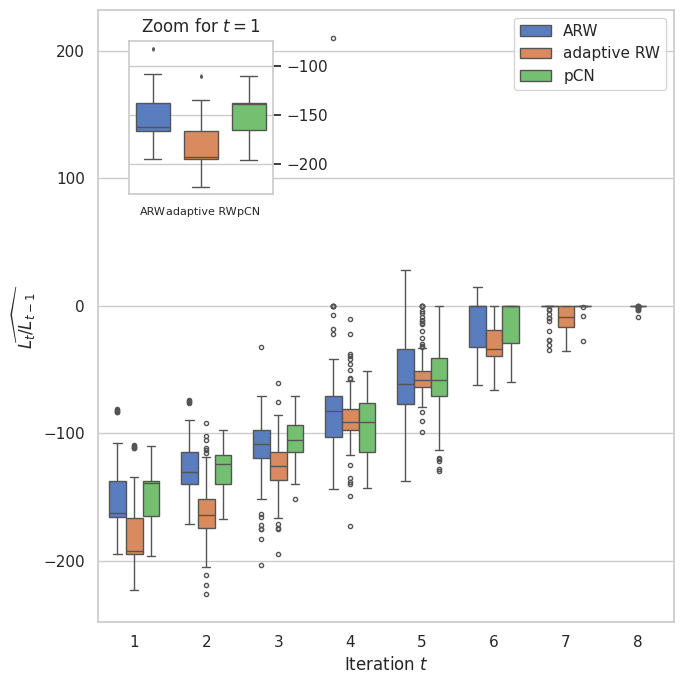

In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Set clean style
sns.set(style='whitegrid', palette='muted', font_scale=1.0)

# Prepare data
dfs = []
for proposal in idx_proposal:
    for idx in range(len(idx_proposal[proposal])):
        temp_df = pd.DataFrame(
            log_normalization_constants_facteur[proposal][idx][:, :max_temp_idx_per_proposal[proposal]],
            columns=range(1, max_temp_idx_per_proposal[proposal]+1)
        ).assign(Type=proposal)
        dfs.append(temp_df)

melted_df = pd.concat(dfs).melt(id_vars=['Type'], var_name='Iteration', value_name='Value')

# Create figure
fig, ax = plt.subplots(figsize=(7, 7))

# Main plot
sns.boxplot(
    x='Iteration',
    y='Value',
    hue='Type',
    data=melted_df,
    ax=ax,
    linewidth=1,
    width=0.7,
    fliersize=3
)

# Inset plot with adjusted borderpad
ax_inset = inset_axes(ax, width="25%", height="25%", loc='upper left', borderpad=2.)
sns.boxplot(
    x='Type',
    y='Value',
    data=melted_df[melted_df['Iteration'] == 1],
    ax=ax_inset,
    palette='muted',
    linewidth=1,
    width=0.7,
    fliersize=3*1/5
)

# Move y-axis labels to the right for the inset plot
ax_inset.yaxis.set_ticks_position('right')
ax_inset.yaxis.set_label_position('right')

ax_inset.tick_params(axis='x', labelsize=8)

# Styling
ax.set(xlabel=r'Iteration $t$', ylabel=r'$\widehat{L_t/L_{t-1}}$')
ax_inset.set(title=r'Zoom for $t=1$', xlabel='', ylabel='')

# Clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

plt.tight_layout()
plt.savefig(DIR + "log_normalisation.pdf", dpi=300, bbox_inches='tight')
plt.show()
